### Synthetic Data Generation Via Euler–Maruyama Monte Carlo Simulation

```
┌─────────────────────────────────────────────────────────┐
│  SETUP                                                  │
│  Set ℙ params: μ, κ, α_P, σ₁, σ₂, ρ                     │
│  Set ℚ params: r, λ₂  →  α_Q = α_P - σ₂λ₂/κ             │
│  Set S₀=100, T=10, N=1000, M=100                        │
│  dt = T/N,  t = [0, dt, 2dt, ..., T]  (N+1 points)      │
└─────────────────────┬───────────────────────────────────┘
                      │
                      ▼
┌─────────────────────────────────────────────────────────┐
│  INITIALISE STATE ARRAYS  (M × N+1)                     │
│  X[:,0]     = ln(S₀)   for all M paths                  │
│  δ[:,0]     = α_P      for all M paths                  │
│  Seed PRNG: key = PRNGKey(0)                            │
└─────────────────────┬───────────────────────────────────┘
                      │
                      ▼
┌─────────────────────────────────────────────────────────┐
│  EULER–MARUYAMA LOOP  (under ℙ)   n = 0, 1, ..., N-1    │
│                                                         │
│  1. Split key → subkey0, subkey1                        │
│                                                         │
│  2. Draw independent normals (shape M):                 │
│       z₀, z₁ ~ N(0,1)                                   │
│                                                         │
│  3. Cholesky-correlated Brownian increments:            │
│       dW₁ = √dt · z₀                                    │
│       dW₂ = √dt · (ρ·z₀ + √(1-ρ²)·z₁)                   │
│       → Cov(dW₁, dW₂) = ρ·dt  ✓                         │
│                                                         │
│  4. Euler step — log spot (Itô-corrected):              │
│       X_{n+1} = X_n + (μ - δ_n - ½σ₁²)dt + σ₁·dW₁       │
│                       └── Itô correction ──┘            │
│                                                         │
│  5. Euler step — convenience yield (OU process):        │
│       δ_{n+1} = δ_n + κ(α_P - δ_n)dt + σ₂·dW₂           │
│                        └── mean reversion ──┘           │
└─────────────────────┬───────────────────────────────────┘
                      │  (after N steps)
                      ▼
┌─────────────────────────────────────────────────────────┐
│  RECOVER SPOT PRICE                                     │
│  S = exp(X)    shape: M × N+1                           │
└─────────────────────┬───────────────────────────────────┘
                      │
          ┌───────────┴──────────────┐
          │  MEASURE SWITCH: ℙ → ℚ   │
          └───────────┬──────────────┘
                      ▼
┌─────────────────────────────────────────────────────────┐
│  PRICE FUTURES PANEL  (closed form under ℚ)             │
│  For every (path, date, maturity) triple:               │
│    F(τ, S, δ) = S · exp(B(τ)·δ + A(τ))                  │
│  F_clean shape: M × N+1 × K   (K=12 maturities)         │
└─────────────────────┬───────────────────────────────────┘
                      │
                      ▼
┌─────────────────────────────────────────────────────────┐
│  ADD OBSERVATION NOISE                                  │
│  log_F_obs = log(F_clean) + ε,  ε ~ N(0, σ_noise²)      │
└─────────────────────┬───────────────────────────────────┘
                      │
                      ▼
┌─────────────────────────────────────────────────────────┐
│  SAVE  mc_data.pkl                                      │
│  ├── S, log_F_obs          → PINN sees these only       │
│  ├── params_P, params_Q    → known / given              │
│  └── delta_true            → eval target, never to PINN │
└─────────────────────────────────────────────────────────┘
```


In [4]:
# closed-form GS futures pricer
from gs_wamol.physics.gibson_schwartz import GSParams, futures, term_structure
import jax.numpy as jnp
import jax
from jax import random, vmap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import json
from pathlib import Path
import pickle

In [5]:
REPO_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_DIR = REPO_ROOT / "config"
DATA_DIR = REPO_ROOT / "data" / "input" / "synthetic"
DATA_DIR.mkdir(parents=True, exist_ok=True) 

In [6]:
def load_params(path: Path) -> dict:
    with open(path) as f:
        return json.load(f)


def simulate_paths(key: jax.Array, p_params: dict, S0: float, T: float, N: int, M: int) -> tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    dt = T / N  # time step size
    sqrt_dt = jnp.sqrt(dt)
    t = jnp.linspace(0, T, N + 1)  # time grid t=0 to T, inclusive

    X = jnp.zeros((M, N + 1))
    delta = jnp.zeros((M, N + 1))
    delta = delta.at[:, 0].set(p_params["alpha_P"])  # delta begins at its long-run mean
    X = X.at[:, 0].set(jnp.log(S0))  # log spot price

    for n in range(N):
        key, subkey0, subkey1 = random.split(key, 3)

        # cholesky-correlated Brownian increments for the two SDEs. dW1 and dW2 are correlated with correlation rho.
        z0 = random.normal(subkey0, shape=(M,))
        z1 = random.normal(subkey1, shape=(M,))
        dW1 = sqrt_dt * z0
        dW2 = (p_params["rho"] * z0 + jnp.sqrt(1 - p_params["rho"] ** 2) * z1) * sqrt_dt

        # Euler-Maruyama step for log spot and convenience yield.
        X = X.at[:, n + 1].set(X[:, n] + (p_params["mu"] - delta[:, n] - 0.5 * p_params["sigma1"] ** 2) * dt + p_params["sigma1"] * dW1)
        delta = delta.at[:, n + 1].set(delta[:, n] + p_params["kappa"] * (p_params["alpha_P"] - delta[:, n]) * dt + p_params["sigma2"] * dW2)

    return t, X, delta


def price_futures(key: jax.Array, X: jnp.ndarray, delta: jnp.ndarray, p_params: dict, q_params: dict, noise_std: float = 0.01) -> tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, GSParams]:
    """Price the maturity panel from each (path, date) state, then add log-price noise.

    Returns
    -------
    taus      : (K,)          contract maturities in years
    F_clean   : (M, N+1, K)   exact closed-form futures prices
    log_F_obs : (M, N+1, K)   noisy observed log futures prices
    p_Q       : GSParams      the risk-neutral parameter set actually used to price
    """
    S = jnp.exp(X)  # (M, N+1) spot price paths, out of log space for the pricer

    # measure change: only the long-run level shifts. kappa, sigma1, sigma2, rho are
    # measure-invariant and are reused from p_params verbatim -- do not "convert" them.
    alpha_Q = p_params["alpha_P"] - p_params["sigma2"] * q_params["lambda2"] / p_params["kappa"]

    # fixed maturities held constant across dates (CL1..CL12-style panel),
    # same convention as data/generate.py / data/observe.py
    taus = jnp.arange(1, 13) / 12.0  # (K,) years: 1mo, 2mo, ..., 12mo

    p_Q = GSParams(r=q_params["r"], kappa=p_params["kappa"], alpha_Q=alpha_Q,
                   sigma1=p_params["sigma1"], sigma2=p_params["sigma2"], rho=p_params["rho"])

    def price_curve(S_pt: float, delta_pt: float) -> jnp.ndarray:
        # S_pt, delta_pt are scalars: one path, one date. term_structure vmaps the
        # closed-form futures() over the maturity axis internally.
        return term_structure(taus, S_pt, delta_pt, p_Q)  # (K,)

    # vmap over dates, then over paths, pricing every (path, date) state across all K maturities
    price_over_dates = vmap(price_curve, in_axes=(0, 0))       # (N+1,) x (N+1,) -> (N+1, K)
    price_over_paths = vmap(price_over_dates, in_axes=(0, 0))  # (M, N+1) x (M, N+1) -> (M, N+1, K)

    F_clean = price_over_paths(S, delta)  # (M, N+1, K) exact closed-form futures prices
    log_F_clean = jnp.log(F_clean)        # log-price panel, matches observe.py's convention

    # add measurement noise to simulate observed market quotes (for PINN inversion downstream).
    # all noise enters here, in the observation layer only -- never in the pricer.
    log_F_obs = log_F_clean + noise_std * random.normal(key, shape=log_F_clean.shape)
    return taus, F_clean, log_F_obs, p_Q


def validate(X, delta, taus, F_clean, p_Q, p_params):
    """Post-simulation sanity checks. Printed, not asserted -- these are diagnostics
    for the thesis write-up, not a test suite (that lives in tests/test_synthetic_gs.py).
    """
    S = jnp.exp(X)

    # the simulation actually stepped: a dedented Euler update leaves interior
    # columns at their initialised zero, which is otherwise invisible in the shapes
    print(f"all dates populated : {bool(jnp.all(X != 0.0))}")
    print(f"spot stays positive : {bool(jnp.all(S > 0))}")

    # realised Brownian correlation should recover rho. dX is dominated by its
    # diffusion term over a short step, so corr(dX, d delta) ~= rho.
    dX, ddelta = jnp.diff(X, axis=1), jnp.diff(delta, axis=1)
    corr = float(jnp.corrcoef(dX.ravel(), ddelta.ravel())[0, 1])
    print(f"corr(dW1, dW2)      : {corr:.4f}  (rho = {p_params['rho']})")

    # delta is an OU process, so its terminal spread should match the stationary
    # standard deviation sigma2 / sqrt(2 kappa)
    stat_sd = p_params["sigma2"] / (2 * p_params["kappa"]) ** 0.5
    print(f"delta mean at T     : {float(delta[:, -1].mean()):.4f}  (alpha_P = {p_params['alpha_P']})")
    print(f"delta sd at T       : {float(delta[:, -1].std()):.4f}  (stationary = {stat_sd:.4f})")

    # F_hat(tau=0, S, delta) must equal S exactly -- the pricing PDE's initial
    # condition. float32 (JAX default) floors this around ~1e-5.
    ic_err = float(jnp.max(jnp.abs(futures(0.0, S[:, 0], delta[:, 0], p_Q) - S[:, 0])))
    print(f"F_hat(tau=0) - S    : {ic_err:.2e}  (float32 floor ~1e-5)")

    # the shortest maturity should sit closer to spot in log-price than the longest,
    # since |B(tau)| grows monotonically with tau
    log_S = jnp.log(S)
    log_F = jnp.log(F_clean)
    frac_ok = float(jnp.mean(jnp.abs(log_F[:, :, 0] - log_S) <= jnp.abs(log_F[:, :, -1] - log_S)))
    print(f"short-tau closer    : {frac_ok:.1%} of (path, date) cells")


def save_dataset(mc_data: dict, path: Path) -> Path:
    """Pickle the dataset to `path`, creating the parent directory if needed."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(mc_data, f)
    print(f"saved {path} ({path.stat().st_size / 1e6:.1f} MB)")
    return path


def main(seed: int = 0, S0: float = 100.0, T: float = 10.0, N: int = 1000, M: int = 100, noise_std: float = 0.01) -> dict:  # noqa: D417
    """Simulate -> price -> add noise -> save. Returns the dataset dict."""
    # load once here, then pass down: keeps simulate_paths/price_futures pure
    # and testable without touching the filesystem
    p_params = load_params(CONFIG_DIR / "p_params.json")
    q_params = load_params(CONFIG_DIR / "q_params.json")

    # distinct keys: path noise and measurement noise must be independent draws
    path_key, obs_key = random.split(random.PRNGKey(seed))

    t, X, delta = simulate_paths(path_key, p_params, S0, T, N, M)
    taus, F_clean, log_F_obs, p_Q = price_futures(obs_key, X, delta, p_params, q_params, noise_std)

    validate(X, delta, taus, F_clean, p_Q, p_params)

    mc_data = {
        't_grid': t,              # (N+1,) simulation dates
        'taus': taus,             # (K,) fixed contract maturities, years
        'X': X,                   # (M, N+1) log spot paths
        'S': jnp.exp(X),          # (M, N+1) spot price paths
        'delta_true': delta,      # (M, N+1) TRUE latent convenience yield -- eval target only, never feed to inversion
        'F_clean': F_clean,       # (M, N+1, K) exact closed-form futures prices
        'log_F_obs': log_F_obs,   # (M, N+1, K) noisy observed log futures prices
        'params_P': p_params,
        'params_Q': p_Q,
        'alpha_Q': p_Q.alpha_Q,
        'lambda2': q_params["lambda2"],
        'M': M,
        'N': N,
        'T': T,
        'seed': seed,
        'noise_std': noise_std,
    }
    save_dataset(mc_data, DATA_DIR / "mc_data.pkl")
    return mc_data


if __name__ == "__main__":
    mc_data = main()

    # bind the fields the plotting cells below read as bare globals
    t = mc_data['t_grid']
    X, S, delta = mc_data['X'], mc_data['S'], mc_data['delta_true']
    taus, F_clean, log_F_obs = mc_data['taus'], mc_data['F_clean'], mc_data['log_F_obs']
    p_Q, alpha_Q, lambda2 = mc_data['params_Q'], mc_data['alpha_Q'], mc_data['lambda2']
    M, N, T = mc_data['M'], mc_data['N'], mc_data['T']
    alpha_P = mc_data['params_P']['alpha_P']

W0719 17:55:00.591141 22999411 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


all dates populated : True
spot stays positive : True
corr(dW1, dW2)      : 0.7665  (rho = 0.766)
delta mean at T     : 0.0767  (alpha_P = 0.106)
delta sd at T       : 0.2846  (stationary = 0.2721)
F_hat(tau=0) - S    : 0.00e+00  (float32 floor ~1e-5)
short-tau closer    : 95.9% of (path, date) cells
saved /Users/evanlynch/Developer/AC-PINNs/data/mc_data.pkl (10.8 MB)


In [7]:
colors = cm.viridis(jnp.linspace(0, 1, M))  # one color per path, for the plots below

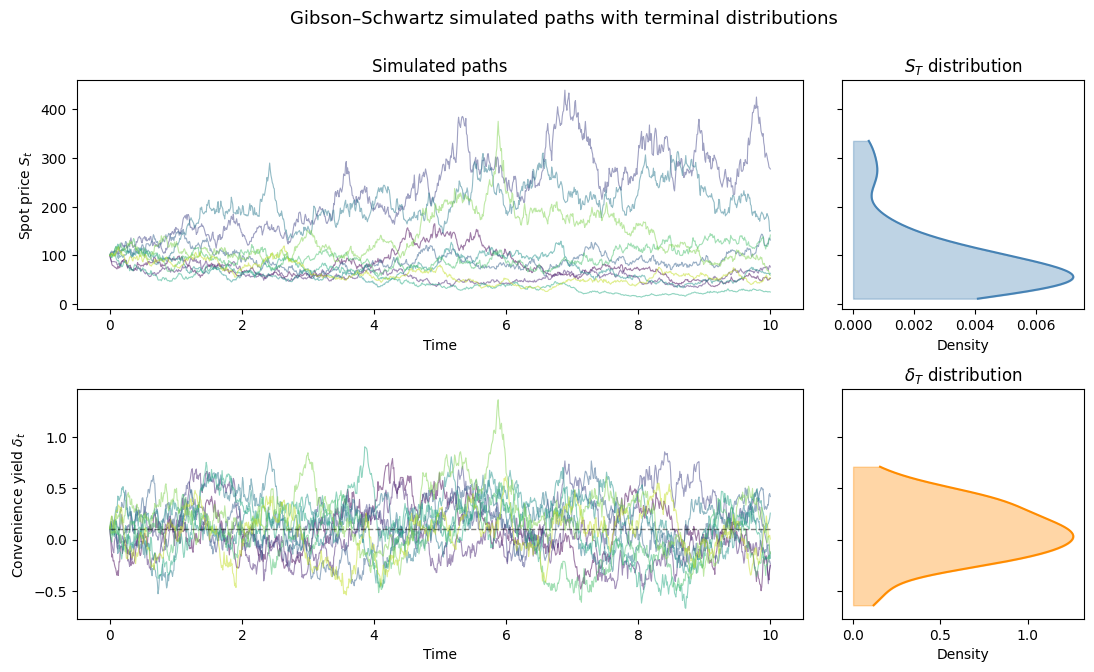

In [8]:
import numpy as np
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(2, 2, width_ratios=[3, 1], hspace=0.35, wspace=0.08)

ax_s      = fig.add_subplot(gs[0, 0])
ax_s_dist = fig.add_subplot(gs[0, 1], sharey=ax_s)
ax_d      = fig.add_subplot(gs[1, 0])
ax_d_dist = fig.add_subplot(gs[1, 1], sharey=ax_d)

# spot price paths (every 10th path for clarity)
for i in range(0, M, 10):
    ax_s.plot(t, jnp.exp(X[i, :]), color=colors[i], alpha=0.5, lw=0.8)
ax_s.set_ylabel('Spot price $S_t$')
ax_s.set_xlabel('Time')
ax_s.set_title('Simulated paths')

# KDE of S_T, the terminal distribution
S_T = np.array(jnp.exp(X[:, -1]))
s_vals = np.linspace(S_T.min(), S_T.max(), 300)
kde_s = gaussian_kde(S_T)
ax_s_dist.fill_betweenx(s_vals, kde_s(s_vals), alpha=0.35, color='steelblue')
ax_s_dist.plot(kde_s(s_vals), s_vals, color='steelblue', lw=1.5)
ax_s_dist.set_xlabel('Density')
ax_s_dist.set_title('$S_T$ distribution')
ax_s_dist.tick_params(labelleft=False)

# convenience yield paths
for i in range(0, M, 10):
    ax_d.plot(t, delta[i, :], color=colors[i], alpha=0.5, lw=0.8)
ax_d.set_ylabel('Convenience yield $\\delta_t$')
ax_d.set_xlabel('Time')
ax_d.hlines(y=alpha_P, color='black', lw=1.0, ls='--', alpha=0.5, xmin=t[0], xmax=t[-1])  # reference line at alpha_P

# KDE of delta_T, the terminal distribution
delta_T = np.array(delta[:, -1])
d_vals = np.linspace(delta_T.min(), delta_T.max(), 300)
kde_d = gaussian_kde(delta_T)
ax_d_dist.fill_betweenx(d_vals, kde_d(d_vals), alpha=0.35, color='darkorange')
ax_d_dist.plot(kde_d(d_vals), d_vals, color='darkorange', lw=1.5)
ax_d_dist.set_xlabel('Density')
ax_d_dist.set_title('$\\delta_T$ distribution')
ax_d_dist.tick_params(labelleft=False)

fig.suptitle('Gibson–Schwartz simulated paths with terminal distributions', fontsize=13)
plt.show()

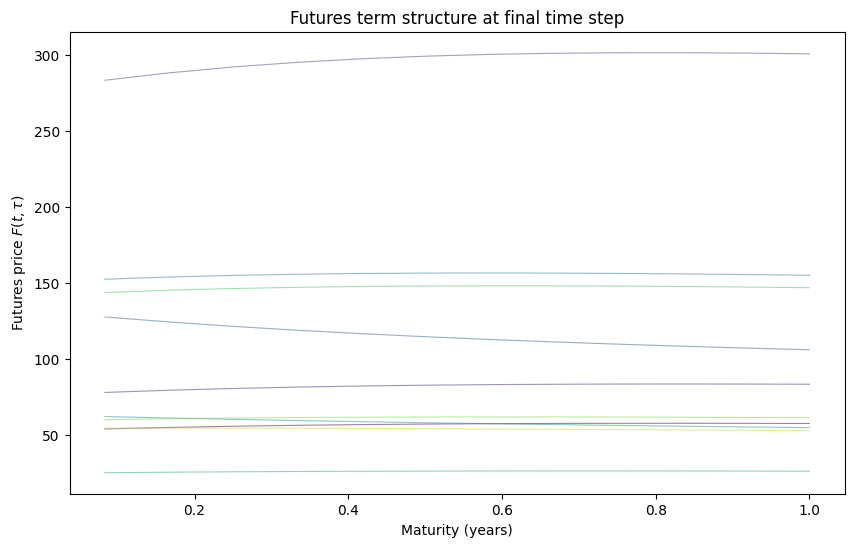

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
# plot the futures term structure at the final time step for a few paths
for i in range(0, M, 10):
    axes.plot(taus, F_clean[i, -1, :], color=colors[i], alpha=0.5, lw=0.8)
axes.set_xlabel('Maturity (years)')
axes.set_ylabel('Futures price $F(t, \\tau)$')
axes.set_title('Futures term structure at final time step')
plt.show()